In [28]:
import numpy as np
import matplotlib.pyplot as plt
import copy
x=np.arange(1,20,1)
y=1+x**2
X=x**2
X=X.reshape(-1,1)
def gradient_descent(X,y,w_in,b_in,alpha,num_iters):
    w=copy.deepcopy(w_in)
    m=X.shape[0]
    b=b_in
    cost_history=[]
    for j in range(num_iters):
        dj_dw=0
        dj_db=0
        for i in range(m):
            dj_dw_i=(w*X[i,0]+b-y[i])*X[i,0]
            dj_db_i=w*X[i,0]+b-y[i]
            dj_dw+=dj_dw_i
            dj_db+=dj_db_i
        dj_dw=dj_dw/m
        dj_db=dj_db/m
        w=w-alpha*dj_dw
        b=b-alpha*dj_db
        if j%100==0:
            cost=(1/(2*m))*np.sum((w*X[:,0]+b-y[i])**2)
            cost_history.append(cost)
            print(f"Iteration:{i} Cost: {cost_history[-1]:.4f}  w:{w:.4f} b:{b:.4f}")
    return w,b
w_init=0
b=0
model_w,model_b=gradient_descent(X,y,w_init,b,5.0e-7,1000)
print(f"经过梯度下降得到的结果：w:{model_w:.4f} b:{model_b:.4f}")


Iteration:18 Cost: 64825.3751  w:0.0149 b:0.0001
Iteration:18 Cost: 37780.6168  w:0.7818 b:0.0035
Iteration:18 Cost: 34096.3577  w:0.9543 b:0.0042
Iteration:18 Cost: 33388.9785  w:0.9931 b:0.0044
Iteration:18 Cost: 33235.9860  w:1.0018 b:0.0045
Iteration:18 Cost: 33201.8763  w:1.0038 b:0.0045
Iteration:18 Cost: 33194.2158  w:1.0042 b:0.0045
Iteration:18 Cost: 33192.4907  w:1.0043 b:0.0046
Iteration:18 Cost: 33192.1001  w:1.0044 b:0.0046
Iteration:18 Cost: 33192.0097  w:1.0044 b:0.0046
经过梯度下降得到的结果：w:1.0044 b:0.0046


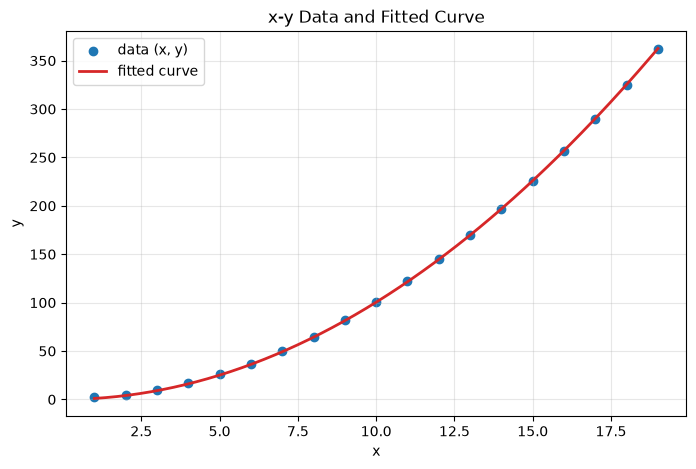

In [25]:
# 绘制原始 x、y 数据和梯度下降得到的拟合曲线
x_plot = np.linspace(x.min(), x.max(), 200)
y_fit = model_w * x_plot**2 + model_b

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='tab:blue', label='data (x, y)')
plt.plot(x_plot, y_fit, color='tab:red', linewidth=2, label='fitted curve')
plt.xlabel('x')
plt.ylabel('y')
plt.title('x-y Data and Fitted Curve')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [64]:
import numpy as np
import matplotlib.pyplot as plt
x=np.arange(1,20,1)
y=1+x**2

def gradient_descent(X,y,alpha,num_iters):
    m,n=X.shape
    w=np.zeros(n)
    b=0
    cost_history=[]
    for i in range(num_iters):
        f_wb=np.dot(X,w)+b
        w=w-alpha*((1/m)*(X.T@(f_wb-y)))
        b=b-alpha*((1/m)*np.sum(f_wb-y))
        if i%100==0:
            cost=(1/(2*m))*np.sum((f_wb-y)**2)
            cost_history.append(cost)
            print(f"Iteration:{i} Cost: {cost_history[-1]:.4f}  w:{w[0]:.4f} b:{b:.4f}")
    return w,b

def feature_scaling(x):
    u_j=np.mean(x,axis=0)
    sigema=np.std(x,axis=0)
    nom_x=(x-u_j)/sigema
    return nom_x

X=x.reshape(-1,1)
model_w,model_b=gradient_descent(X,y,1.0e-2,1000)
print(f"经过迭代后的结果： w:{model_w[0]:.4f} b:{model_b:.4f}")
print()

X1=np.c_[x,x**2,x**3]    #以列的形式排列每一个元素
model_w1,model_b1=gradient_descent(X1,y,2.0e-7,1000)
print(f"经过迭代后的结果： w:{model_w1} b:{model_b1:.4f}")
print()

X2=feature_scaling(X1)
model_w2,model_b2=gradient_descent(X2,y,1.0e-1,1000)
print(f"经过迭代后的结果： w:{model_w2} b:{model_b2:.4f}")

Iteration:0 Cost: 14937.5000  w:19.1000 b:1.3100
Iteration:100 Cost: 715.4297  w:15.7150 b:-13.3931
Iteration:200 Cost: 583.4189  w:16.5943 b:-24.8040
Iteration:300 Cost: 500.0281  w:17.2932 b:-33.8733
Iteration:400 Cost: 447.3504  w:17.8486 b:-41.0816
Iteration:500 Cost: 414.0740  w:18.2901 b:-46.8106
Iteration:600 Cost: 393.0535  w:18.6410 b:-51.3640
Iteration:700 Cost: 379.7749  w:18.9199 b:-54.9830
Iteration:800 Cost: 371.3868  w:19.1415 b:-57.8594
Iteration:900 Cost: 366.0881  w:19.3177 b:-60.1455
经过迭代后的结果： w:19.4565 b:-61.9463

Iteration:0 Cost: 14937.5000  w:0.0004 b:0.0000
Iteration:100 Cost: 407.7688  w:0.0028 b:0.0003
Iteration:200 Cost: 394.4050  w:0.0053 b:0.0007
Iteration:300 Cost: 381.4792  w:0.0078 b:0.0010
Iteration:400 Cost: 368.9771  w:0.0102 b:0.0013
Iteration:500 Cost: 356.8848  w:0.0126 b:0.0016
Iteration:600 Cost: 345.1888  w:0.0149 b:0.0019
Iteration:700 Cost: 333.8762  w:0.0172 b:0.0022
Iteration:800 Cost: 322.9344  w:0.0195 b:0.0025
Iteration:900 Cost: 312.3512

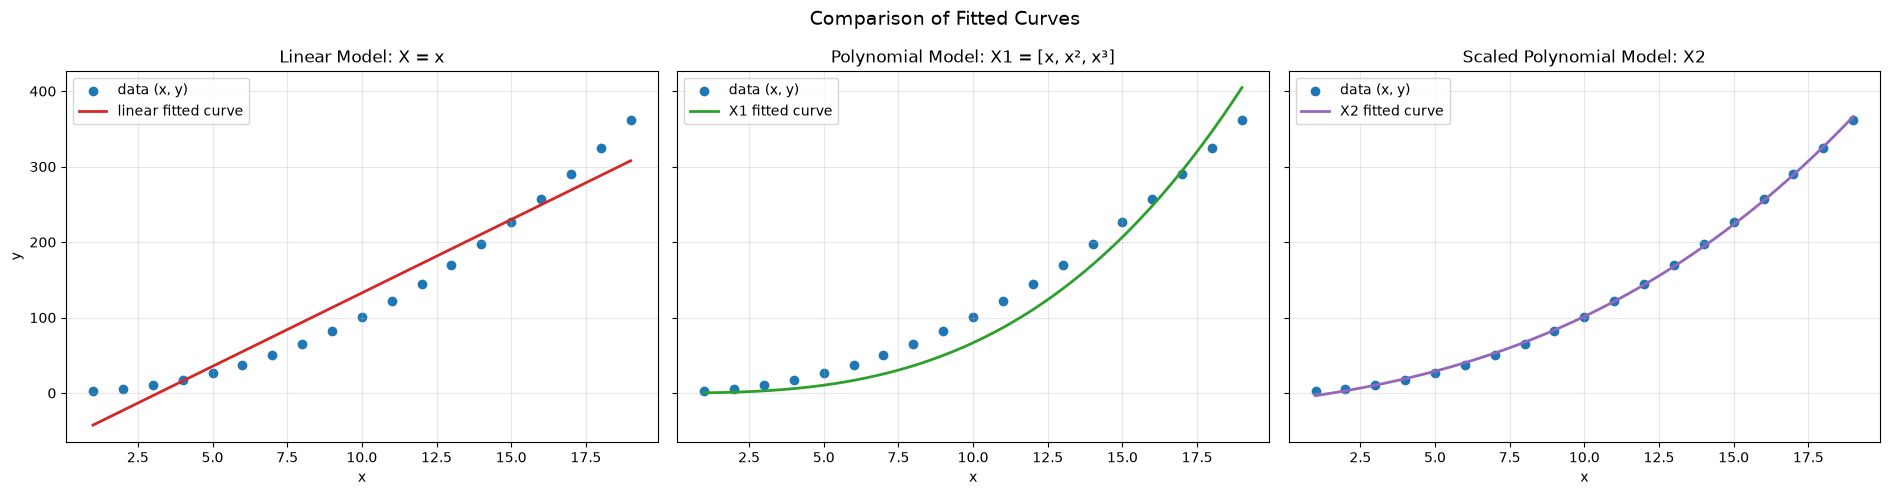

In [65]:
# 使用 subplot 横向比较 X、X1 和标准化后的 X2 模型
x_plot = np.linspace(x.min(), x.max(), 200)
y_fit = model_w[0] * x_plot + model_b
X1_plot = np.c_[x_plot, x_plot**2, x_plot**3]
y_fit1 = X1_plot @ model_w1 + model_b1
# X2 必须使用训练数据 X1 的均值和标准差进行标准化
X2_plot = (X1_plot - X1.mean(axis=0)) / X1.std(axis=0)
y_fit2 = X2_plot @ model_w2 + model_b2

fig, axes = plt.subplots(1, 3, figsize=(19, 5), sharey=True)

axes[0].scatter(x, y, color='tab:blue', label='data (x, y)')
axes[0].plot(x_plot, y_fit, color='tab:red', linewidth=2, label='linear fitted curve')
axes[0].set_title('Linear Model: X = x')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].scatter(x, y, color='tab:blue', label='data (x, y)')
axes[1].plot(x_plot, y_fit1, color='tab:green', linewidth=2, label='X1 fitted curve')
axes[1].set_title('Polynomial Model: X1 = [x, x², x³]')
axes[1].set_xlabel('x')
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].scatter(x, y, color='tab:blue', label='data (x, y)')
axes[2].plot(x_plot, y_fit2, color='tab:purple', linewidth=2, label='X2 fitted curve')
axes[2].set_title('Scaled Polynomial Model: X2')
axes[2].set_xlabel('x')
axes[2].grid(alpha=0.3)
axes[2].legend()

fig.suptitle('Comparison of Fitted Curves', fontsize=14)
plt.tight_layout()
plt.show()
